In [43]:
from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import igraph as ig
import leidenalg
import ast
from collections import Counter

In [44]:
CWD = Path.cwd()
DATA = CWD / "data"
df_tweets = pd.read_csv(DATA / 'tweets.csv')
df_users = pd.read_csv(DATA / 'users.csv')

In [45]:
df_users[:2]

,id,location,name,followers_count,statuses_count,time_zone,verified,lang,screen_name,description,created_at,favourites_count,friends_count,listed_count
0,100345056.0,still ⬆️Block⤵️Corner⬇️street,#Ezekiel2517✨...,1053.0,31858.0,NaN,False,en,SCOTTGOHARD,CELEBRITY TRAINER ✨#424W147th✨ #CrossfitCoach ...,Tue Dec 29 23:15:22 +0000 2009,2774.0,1055.0,35.0
1,247165706.0,"Chicago, IL",B E C K S T E R✨,650.0,6742.0,Mountain Time (US & Canada),False,en,Beckster319,Rebecca Lynn Hirschfeld Actress.Model.Writer.A...,Fri Feb 04 06:38:45 +0000 2011,7273.0,896.0,30.0


In [46]:
df_tweets[:2]

,user_id,user_key,created_at,created_str,retweet_count,retweeted,favorite_count,text,tweet_id,source,hashtags,expanded_urls,posted,mentions,retweeted_status_id,in_reply_to_status_id
0,2.532612e+09,kathiemrr,1.488207e+12,2017-02-27 14:54:00,NaN,NaN,NaN,#ThingsDoneByMistake kissing auntie in the lips,8.362279e+17,NaN,"[""ThingsDoneByMistake""]",[],POSTED,[],NaN,NaN
1,2.531160e+09,traceyhappymom,1.471273e+12,2016-08-15 14:50:20,NaN,NaN,NaN,RT @mc_derpin: #TheOlderWeGet the more pessimi...,7.651989e+17,NaN,"[""TheOlderWeGet""]",[],POSTED,[],NaN,NaN


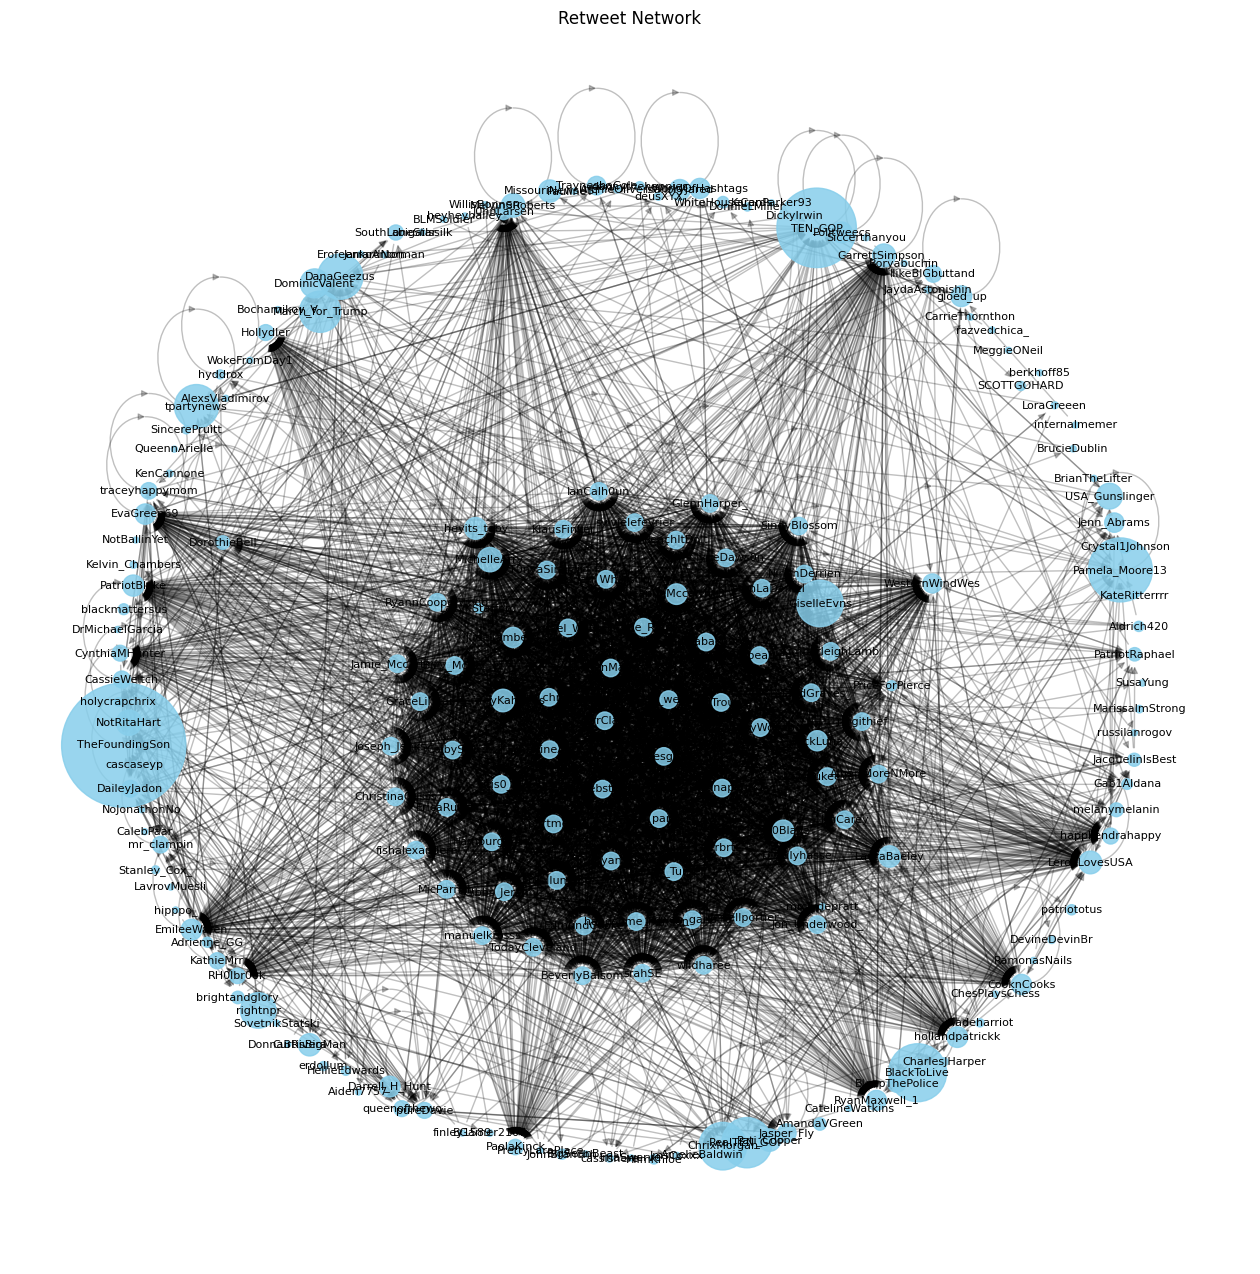

In [47]:
tweets = df_tweets.merge(
    df_users[['id', 'screen_name']],
    left_on='user_id',
    right_on='id',
    how='left'
)

authors = tweets[['tweet_id', 'screen_name']].dropna().drop_duplicates()

retweets = tweets.dropna(subset=['retweeted_status_id'])
retweets = retweets.merge(
    authors,
    left_on='retweeted_status_id',
    right_on='tweet_id',
    how='left',
    suffixes=('', '_original')
)

G = nx.DiGraph()
for _, r in retweets.dropna(subset=['screen_name', 'screen_name_original']).iterrows():
    G.add_edge(r['screen_name'], r['screen_name_original'])

pagerank_scores = nx.pagerank(G)
max_pr = max(pagerank_scores.values())
node_sizes = [8000 * (pagerank_scores.get(node, 0) / max_pr)**1.3 for node in G.nodes()]

plt.figure(figsize=(16, 16))
pos = nx.spring_layout(G, seed=42, k=10, iterations=300, scale=3)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.85)
nx.draw_networkx_edges(G, pos, alpha=0.25, width=1)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Retweet Network")
plt.axis("off")
plt.show()

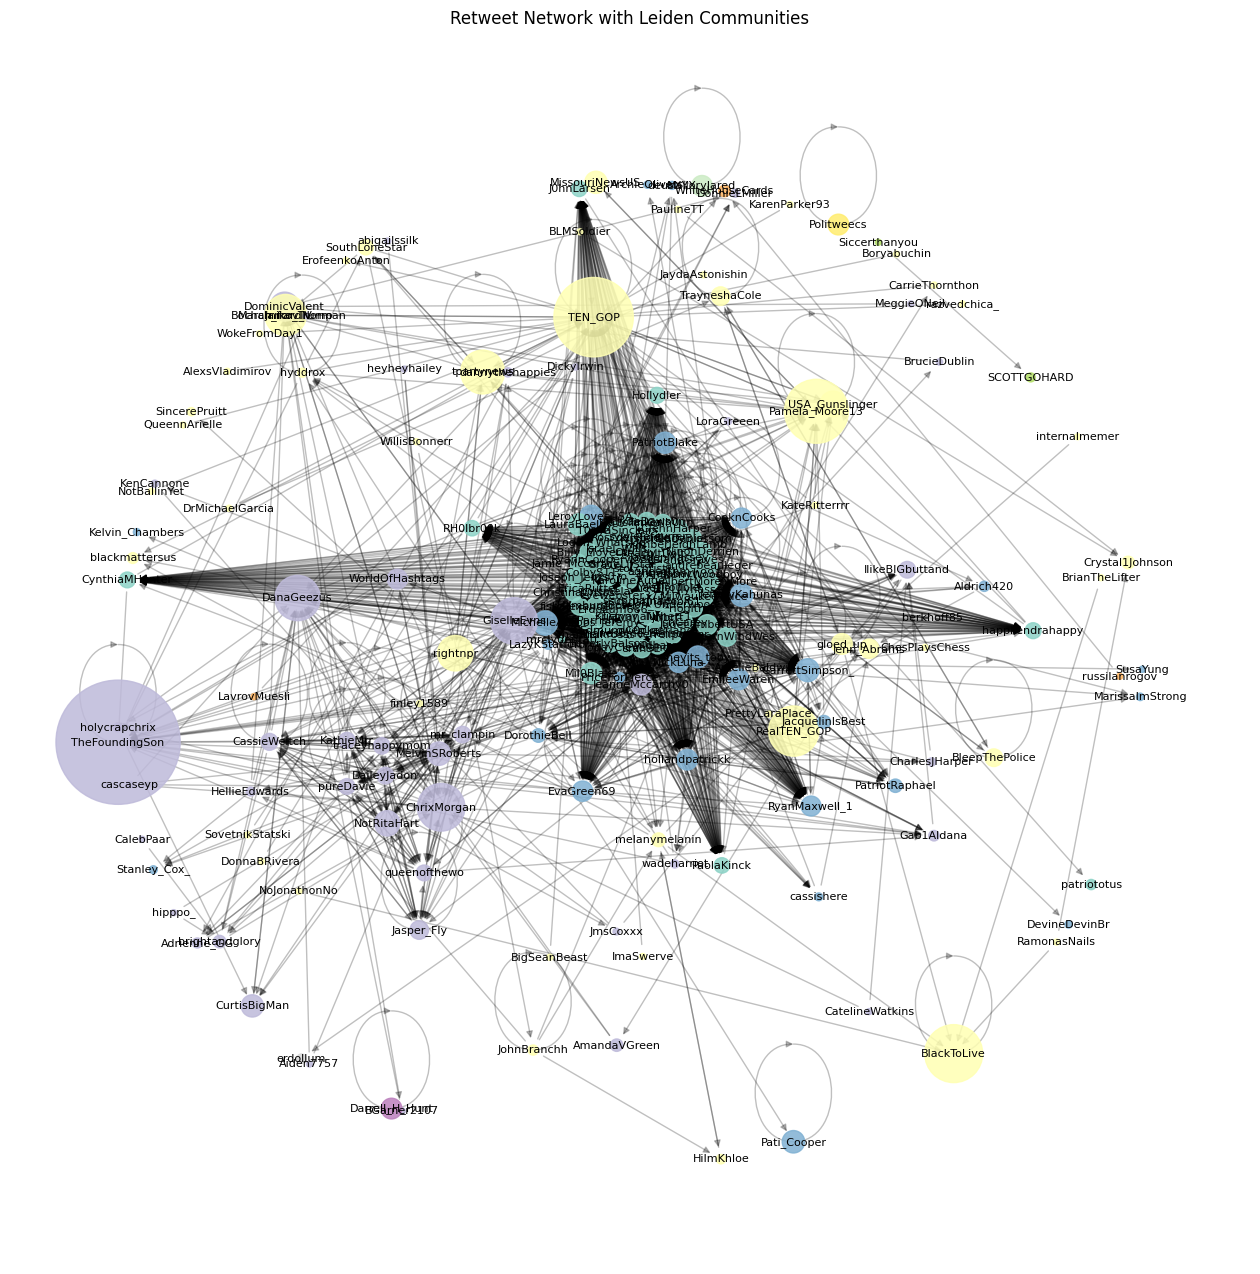

In [48]:
edges = [(u, v) for u, v in G.edges()]
nodes = list(G.nodes())
node_index = {name: i for i, name in enumerate(nodes)}
edges_idx = [(node_index[u], node_index[v]) for u, v in edges]

ig_G = ig.Graph(edges=edges_idx, directed=True) 
partition = leidenalg.find_partition(ig_G, leidenalg.ModularityVertexPartition, weights=None)

node_colors_dict = {nodes[i]: partition.membership[i] for i in range(len(nodes))}
colors = plt.cm.Set3(np.linspace(0, 1, max(partition.membership)+1))
node_colors = [colors[node_colors_dict[n]] for n in nodes]

plt.figure(figsize=(16, 16))
pos = nx.spring_layout(G, seed=42, k=10, iterations=1000, scale=5)
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=[8000 * (pagerank_scores.get(node, 0)/max_pr)**1.3 for node in G.nodes()],
    node_color=node_colors,
    alpha=0.85
)
nx.draw_networkx_edges(G, pos, alpha=0.25, width=1)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Retweet Network with Leiden Communities")
plt.axis("off")
plt.show()

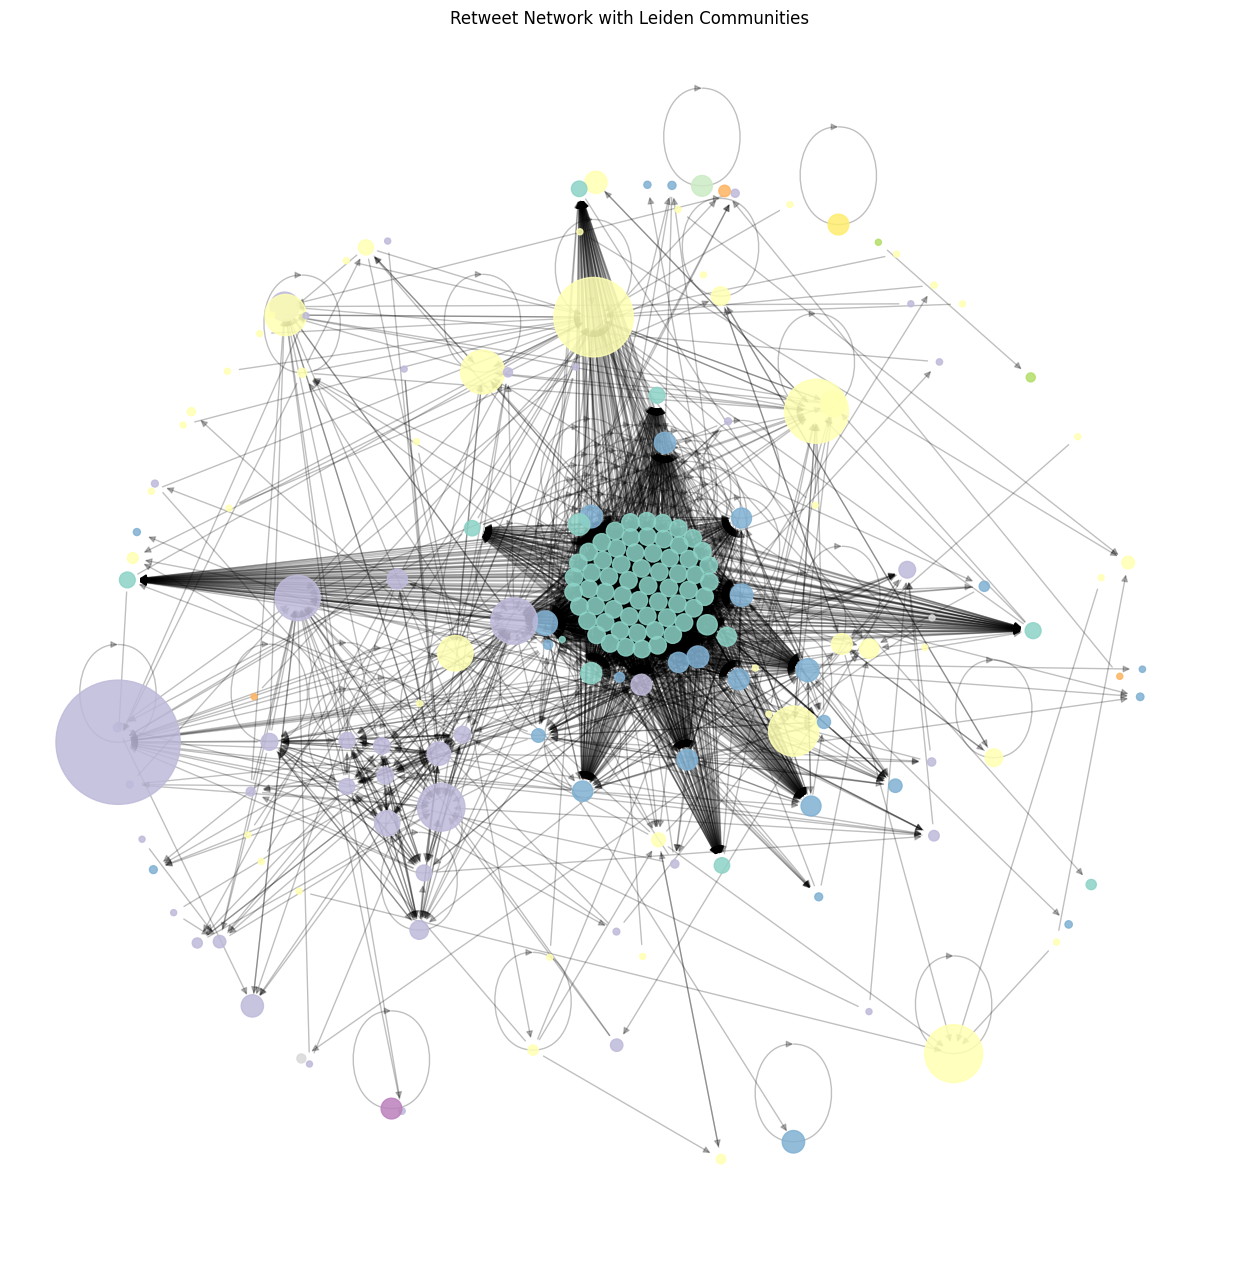

In [49]:
edges = [(u, v) for u, v in G.edges()]
nodes = list(G.nodes())
node_index = {name: i for i, name in enumerate(nodes)}
edges_idx = [(node_index[u], node_index[v]) for u, v in edges]

ig_G = ig.Graph(edges=edges_idx, directed=True) 
partition = leidenalg.find_partition(ig_G, leidenalg.ModularityVertexPartition, weights=None)

node_colors_dict = {nodes[i]: partition.membership[i] for i in range(len(nodes))}
colors = plt.cm.Set3(np.linspace(0, 1, max(partition.membership)+1))
node_colors = [colors[node_colors_dict[n]] for n in nodes]

plt.figure(figsize=(16, 16))
pos = nx.spring_layout(G, seed=42, k=10, iterations=1000, scale=5)
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=[8000 * (pagerank_scores.get(node, 0)/max_pr)**1.3 for node in G.nodes()],
    node_color=node_colors,
    alpha=0.85
)
nx.draw_networkx_edges(G, pos, alpha=0.25, width=1)
plt.title("Retweet Network with Leiden Communities")
plt.axis("off")
plt.show()

In [50]:
nodes = list(G.nodes())
node_community = {nodes[i]: partition.membership[i] for i in range(len(nodes))}

top_users = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:10]

top_users_table = pd.DataFrame(top_users, columns=['user', 'pagerank'])

top_users_table['community'] = top_users_table['user'].map(node_community)

top_users_table.index += 1
top_users_table

,user,pagerank,community
1,TheFoundingSon,0.094067,2
2,TEN_GOP,0.047286,1
3,Pamela_Moore13,0.033905,1
4,BlackToLive,0.029132,1
5,RealTEN_GOP,0.023371,1
6,ChrixMorgan,0.021514,2
7,GiselleEvns,0.020760,2
8,DanaGeezus,0.019909,2
9,tpartynews,0.018962,1
10,March_for_Trump,0.017267,1


In [51]:
node_community = {nodes[i]: partition.membership[i] for i in range(len(nodes))}
tweets['community'] = tweets['screen_name'].map(node_community)

def parse_hashtags(h):
    if isinstance(h, str):
        try:
            return ast.literal_eval(h)
        except:
            return []
    elif isinstance(h, list):
        return h
    else:
        return []

tweets['hashtags_list'] = tweets['hashtags'].apply(parse_hashtags)

community_sizes = Counter(node_community.values())

communities = sorted(set(node_community.values()))
community_tables = {}

for c in communities:
    comm_tweets = tweets[tweets['community'] == c]
    all_hashtags = [tag.lower() for tags in comm_tweets['hashtags_list'] for tag in tags]
    counter = Counter(all_hashtags)
    top5 = counter.most_common(5)
    
    df = pd.DataFrame(top5, columns=['hashtag', 'count'])
    df['community'] = c
    df = df[['community', 'hashtag', 'count']]
    community_tables[c] = df
    
    print(f"\nCommunity {c} top 5 hashtags (users: {community_sizes[c]}):")
    display(df)


Community 0 top 5 hashtags (users: 73):


,community,hashtag,count
0,0,news,9208
1,0,sports,4955
2,0,local,4652
3,0,tcot,4178
4,0,guns4ny,3462



Community 1 top 5 hashtags (users: 49):


,community,hashtag,count
0,1,maga,1585
1,1,trump,1072
2,1,tcot,764
3,1,neverhillary,738
4,1,trumppence16,483



Community 2 top 5 hashtags (users: 44):


...

,community,hashtag,count
0,7,demsinphilly,5
1,7,demconvention,3



Community 8 top 5 hashtags (users: 1):


,community,hashtag,count
0,8,nowplaying,56
1,8,blacklivesmatter,27
2,8,searchesgoogleisashamedof,22
3,8,blacktwitter,19
4,8,rapstationradio,16



Community 9 top 5 hashtags (users: 1):


,community,hashtag,count
0,9,hillaryclinton,86
1,9,trump,79
2,9,clinton,38
3,9,obama,24
4,9,donaldtrump,16


In [52]:
node_community = {nodes[i]: partition.membership[i] for i in range(len(nodes))}

tweets['community'] = tweets['screen_name'].map(node_community)

def parse_hashtags(h):
    if isinstance(h, str):
        try:
            return ast.literal_eval(h)
        except:
            return []
    elif isinstance(h, list):
        return h
    else:
        return []

tweets['hashtags_list'] = tweets['hashtags'].apply(parse_hashtags)

top10_users = [user for user, score in sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:10]]

top_communities = set(node_community[user] for user in top10_users if user in node_community)

community_top_user = {}
for c in top_communities:
    users_in_comm = [user for user in G.nodes() if node_community[user] == c]
    top_user = max(users_in_comm, key=lambda u: pagerank_scores.get(u, 0))
    community_top_user[c] = top_user

rows = []

for c in sorted(top_communities):
    comm_tweets = tweets[tweets['community'] == c]
    all_hashtags = [tag.lower() for tags in comm_tweets['hashtags_list'] for tag in tags]
    counter = Counter(all_hashtags)
    top5 = counter.most_common(5)
    
    for tag, count in top5:
        rows.append({
            'community': c,
            'hashtag': tag,
            'count': count,
            'top_user': community_top_user[c]
        })

top_hashtags_table = pd.DataFrame(rows)
top_hashtags_table = top_hashtags_table.sort_values(['community', 'count'], ascending=[True, False])
top_hashtags_table.reset_index(drop=True, inplace=True)
top_hashtags_table

,community,hashtag,count,top_user
0,1,maga,1585,TEN_GOP
1,1,trump,1072,TEN_GOP
2,1,tcot,764,TEN_GOP
3,1,neverhillary,738,TEN_GOP
4,1,trumppence16,483,TEN_GOP
5,2,rejecteddebatetopics,652,TheFoundingSon
6,2,betteralternativetodebates,545,TheFoundingSon
7,2,thingsyoucantignore,526,TheFoundingSon
8,2,survivalguidetothanksgiving,518,TheFoundingSon
9,2,ihavearighttoknow,508,TheFoundingSon


In [53]:
node_community = {nodes[i]: partition.membership[i] for i in range(len(nodes))}

tweets['community'] = tweets['screen_name'].map(node_community)

def parse_hashtags(h):
    if isinstance(h, str):
        try:
            return ast.literal_eval(h)
        except:
            return []
    elif isinstance(h, list):
        return h
    else:
        return []

tweets['hashtags_list'] = tweets['hashtags'].apply(parse_hashtags)

community_sizes = Counter(node_community.values())
largest_community = max(community_sizes, key=lambda c: community_sizes[c])

comm_tweets = tweets[tweets['community'] == largest_community]

all_hashtags = [tag.lower() for tags in comm_tweets['hashtags_list'] for tag in tags]

counter = Counter(all_hashtags)
top5_hashtags = counter.most_common(5)

top5_table = pd.DataFrame(top5_hashtags, columns=['hashtag', 'count'])
top5_table['community'] = largest_community
top5_table = top5_table[['community', 'hashtag', 'count']]
top5_table.reset_index(drop=True, inplace=True)
top5_table

,community,hashtag,count
0,0,news,9208
1,0,sports,4955
2,0,local,4652
3,0,tcot,4178
4,0,guns4ny,3462


/var/folders/_n/4cslc53j6ls8_fsjchkctxkh0000gn/T/ipykernel_8356/3643945543.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  original_counts = df_tweets.groupby('user_id').apply(lambda x: x['retweeted_status_id'].isna().sum())
/var/folders/_n/4cslc53j6ls8_fsjchkctxkh0000gn/T/ipykernel_8356/3643945543.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  retweet_counts = df_tweets.groupby('user_id').apply(la

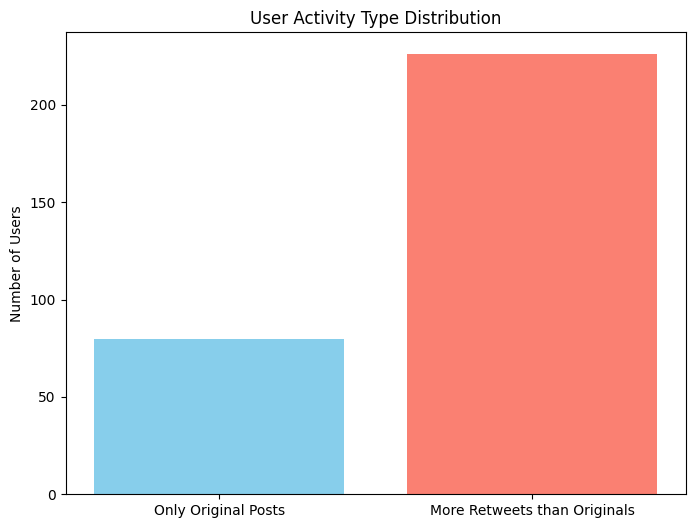

In [54]:
original_counts = df_tweets.groupby('user_id').apply(lambda x: x['retweeted_status_id'].isna().sum())

retweet_counts = df_tweets.groupby('user_id').apply(lambda x: x['retweeted_status_id'].notna().sum())

only_original = (original_counts > 0) & (retweet_counts == 0)
more_retweets = (retweet_counts > original_counts)
counts = {
    'Only Original Posts': only_original.sum(),
    'More Retweets than Originals': more_retweets.sum()
}

plt.figure(figsize=(8, 6))
plt.bar(counts.keys(), counts.values(), color=['skyblue', 'salmon', 'lightgreen'])
plt.ylabel("Number of Users")
plt.title("User Activity Type Distribution")
plt.show()

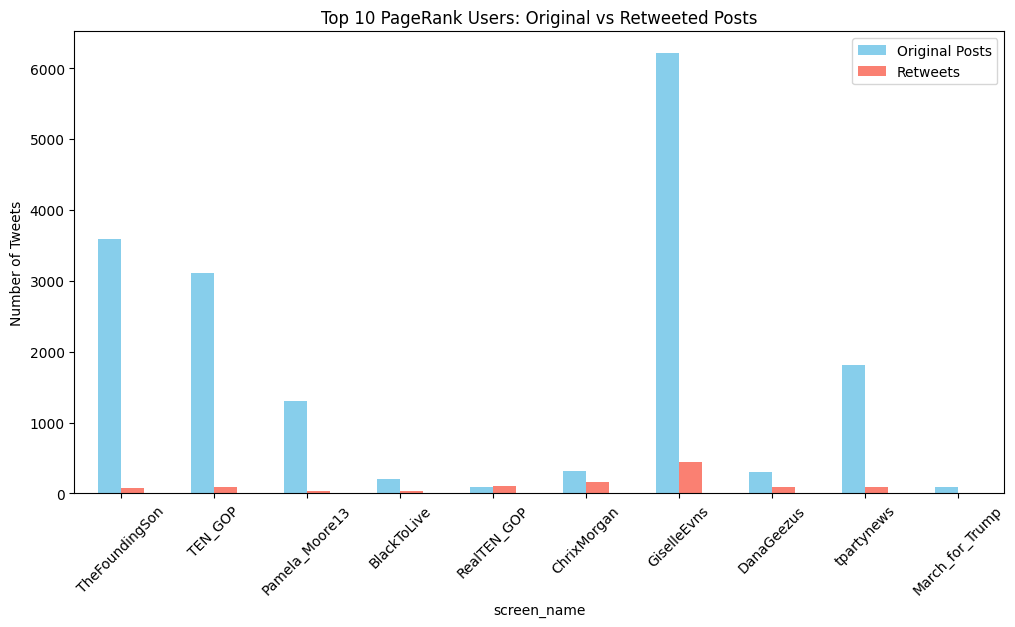

In [55]:
tweets = df_tweets.merge(
    df_users[['id', 'screen_name']],
    left_on='user_id',
    right_on='id',
    how='left'
)

top_users = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:10]
top_usernames = [u for u, _ in top_users]

top_tweets = tweets[tweets['screen_name'].isin(top_usernames)]

original_counts = top_tweets.groupby('screen_name')['retweeted_status_id'].apply(lambda x: x.isna().sum())
retweet_counts = top_tweets.groupby('screen_name')['retweeted_status_id'].apply(lambda x: x.notna().sum())

df_counts = pd.DataFrame({
    'Original Posts': original_counts,
    'Retweets': retweet_counts
}).reindex(top_usernames) 

df_counts.plot(kind='bar', figsize=(12, 6), color=['skyblue', 'salmon'])
plt.ylabel("Number of Tweets")
plt.title("Top 10 PageRank Users: Original vs Retweeted Posts")
plt.xticks(rotation=45)
plt.show()

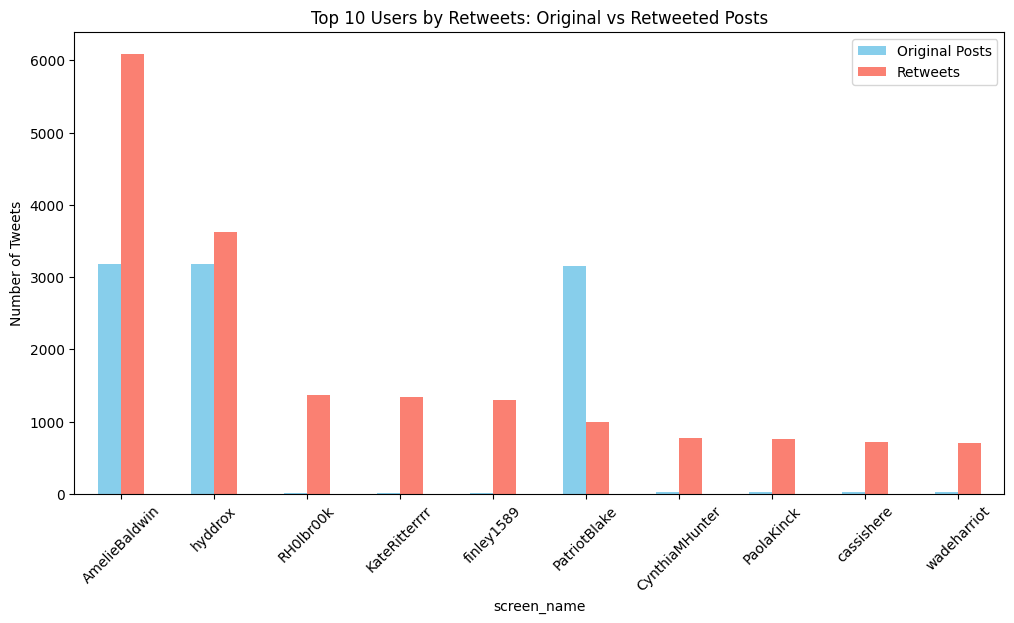

In [56]:
tweets = df_tweets.merge(
    df_users[['id', 'screen_name']],
    left_on='user_id',
    right_on='id',
    how='left'
)

retweet_counts_total = tweets.groupby('screen_name')['retweeted_status_id'].apply(lambda x: x.notna().sum())

top10_retweeters = retweet_counts_total.sort_values(ascending=False).head(10).index.tolist()

top_tweets = tweets[tweets['screen_name'].isin(top10_retweeters)]

original_counts = top_tweets.groupby('screen_name')['retweeted_status_id'].apply(lambda x: x.isna().sum())
retweet_counts = top_tweets.groupby('screen_name')['retweeted_status_id'].apply(lambda x: x.notna().sum())

df_counts = pd.DataFrame({
    'Original Posts': original_counts,
    'Retweets': retweet_counts
}).reindex(top10_retweeters)  

df_counts.plot(kind='bar', figsize=(12, 6), color=['skyblue', 'salmon'])
plt.ylabel("Number of Tweets")
plt.title("Top 10 Users by Retweets: Original vs Retweeted Posts")
plt.xticks(rotation=45)
plt.show()

In [57]:
tweets_merged = df_tweets.merge(
    df_users[['id', 'screen_name']],
    left_on='user_id',
    right_on='id',
    how='left'
)

top5_users = [u for u, _ in sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:5]]

def parse_hashtags(h):
    if isinstance(h, str):
        try:
            return ast.literal_eval(h)
        except:
            return []
    elif isinstance(h, list):
        return h
    else:
        return []

tweets_merged['hashtags_list'] = tweets_merged['hashtags'].apply(parse_hashtags)
original_tweets = tweets_merged[tweets_merged['retweeted_status_id'].isna() & tweets_merged['screen_name'].isin(top5_users)]

results = []
for user in top5_users:
    user_tweets = original_tweets[original_tweets['screen_name'] == user]
    all_hashtags = [tag.lower() for tags in user_tweets['hashtags_list'] for tag in tags]
    counter = Counter(all_hashtags)
    top5_hashtags = counter.most_common(5)
    for tag, count in top5_hashtags:
        results.append({'User': user, 'Hashtag': tag, 'Count': count})

df_hashtags = pd.DataFrame(results)
df_hashtags

,User,Hashtag,Count
0,TheFoundingSon,trump2016,93
1,TheFoundingSon,wakeupamerica,85
2,TheFoundingSon,tcot,53
3,TheFoundingSon,liberallogic,48
4,TheFoundingSon,hillaryforprison,39
5,TEN_GOP,debate,108
6,TEN_GOP,debatenight,107
7,TEN_GOP,rncincle,63
8,TEN_GOP,demsinphilly,58
9,TEN_GOP,blacklivesmatter,44
